In [ ]:
# Carga de librerías para trabajar con series, grafos, modelos y métricas.
import torch
from scipy.io import arff
import pandas as pd
import numpy as np
import networkx as nx
from ts2vg import NaturalVG
import matplotlib.pyplot as plt
from torch_geometric.data import Data

import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool
import copy
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, r2_score
from sklearn.model_selection import train_test_split


c:\repositorios\MULCIA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Utilidad para leer ficheros ARFF y convertir etiquetas binarias a texto.
def path_arff_to_df(path, verbose = False):
    data, meta = arff.loadarff(path)
    df = pd.DataFrame(data)

    if verbose:
        print(meta)

    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].apply(
                lambda x: x.decode("utf-8") if isinstance(x, bytes) else x
            )

    if verbose:
        print(df.head())

    return df

In [ ]:
# Conversión de una serie temporal en un Natural Visibility Graph.
def create_visibility_graph(sequence, graph=False):
    """
    Crea un grafo para una subserie con aristas del Natural Visibility Graph (NaturalVG, ts2vg).
    Los valores de la serie son los atributos de los nodos.
    """
    if torch.is_tensor(sequence):
        ts = sequence.detach().cpu().float().numpy().ravel()
    else:
        ts = np.asarray(sequence, dtype=np.float64).ravel()
    n = len(ts)

    vg = NaturalVG()
    vg.build(ts)
    edges = vg.edges

    edge_index = [[i, j] for i, j in edges] # solo informan al futuro

    if graph:
        G = nx.Graph()
        G.add_edges_from(edges)
        pos = {i: (i, float(ts[i])) for i in range(n)}
        plt.figure(figsize=(8, 6))
        nx.draw(
            G,
            pos,
            with_labels=True,
            node_color="lightblue",
            edge_color="gray",
            node_size=700,
        )
        plt.title("Natural Visibility Graph (NaturalVG / ts2vg)")
        plt.xlabel("índice")
        plt.ylabel("valor")
        plt.show()

    if not edge_index:
        edge_index_t = torch.empty((2, 0), dtype=torch.long)
    else:
        edge_index_t = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    x = torch.tensor(ts, dtype=torch.float).view(-1, 1)

    return Data(x=x, edge_index=edge_index_t)


In [4]:
# Definición de los modelos base: RNN secuencial y GCN sobre grafos de visibilidad.
class RNNClassifier(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, num_classes=2):
        super().__init__()
        self.rnn = nn.RNN(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True,
            nonlinearity="relu",
            bias=False,
        )
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        return self.fc(out)


class GCN_for_VG(nn.Module):

    def __init__(self, in_features, hidden_dim, num_classes, dropout=0.35):
        super().__init__()
        self.dropout = dropout
        self.conv1 = GCNConv(in_features, hidden_dim, bias=True)
        self.conv2 = GCNConv(hidden_dim, hidden_dim, bias=True)
        self.conv3 = GCNConv(hidden_dim, hidden_dim, bias=True)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, x, edge_index, batch, ptr=None, edge_weight=None):
        h = self.conv1(x, edge_index, edge_weight=edge_weight)
        h = self.bn1(h)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        h = self.conv2(h, edge_index, edge_weight=edge_weight)
        h = self.bn2(h)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        h = self.conv3(h, edge_index, edge_weight=edge_weight)
        h = self.bn3(h)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        g_mean = global_mean_pool(h, batch)
        return self.head(g_mean)


# Datos sintéticos

In [ ]:
# Generación del dataset sintético de clasificación con patrones diferenciados por clase.
RNG_SINT = 42
SEQ_LEN_SINT = 20
N_CLASSES_SINT = 6
N_TRAIN_SINT = 600
N_TEST_SINT = 1200
N_TOTAL_SINT = N_TRAIN_SINT + N_TEST_SINT
np.random.seed(RNG_SINT)


def _series_structured_for_class(cls: int, seq_len: int, rng: np.random.Generator) -> np.ndarray:
    t = np.linspace(0.0, 1.0, seq_len, dtype=np.float64)
    noise = rng.normal(0.0, 0.045, size=seq_len)

    if cls == 0:
        # casi monótona creciente
        slope = rng.uniform(0.65, 1.35)
        return slope * t + rng.uniform(-0.12, 0.12) + noise
    if cls == 1:
        # casi monótona decreciente
        slope = rng.uniform(0.65, 1.35)
        return slope * (1.0 - t) + rng.uniform(-0.12, 0.12) + noise
    if cls == 2:
        # campaniforme
        mu = rng.uniform(0.32, 0.68)
        w = rng.uniform(0.11, 0.24)
        h = rng.uniform(0.95, 1.45)
        return h * np.exp(-0.5 * ((t - mu) / w) ** 2) + noise
    if cls == 3:
        # forma de U
        mu = rng.uniform(0.32, 0.68)
        w = rng.uniform(0.11, 0.24)
        h = rng.uniform(0.95, 1.45)
        return 1 -h * np.exp(-0.5 * ((t - mu) / w) ** 2) + noise
    if cls == 4:
        # mucha oscilacion
        f = rng.uniform(3.8, 8.5)
        ph = rng.uniform(0.0, 2 * np.pi)
        amp = rng.uniform(0.55, 1.0)
        return 0.5 + amp * np.sin(2 * np.pi * f * t + ph) + noise
    # cls == 5: diente de sierra
    tri = np.abs(2.0 * (t - 0.5))
    return tri * rng.uniform(0.85, 1.35) + rng.uniform(-0.12, 0.12) + noise


rng_sint = np.random.default_rng(RNG_SINT)
_labels_sint = np.tile(np.arange(N_CLASSES_SINT), N_TOTAL_SINT // N_CLASSES_SINT)
rng_sint.shuffle(_labels_sint)
X_sint = np.asarray(
    [_series_structured_for_class(int(c), SEQ_LEN_SINT, rng_sint) for c in _labels_sint],
    dtype=np.float32,
)
y_sint = _labels_sint.astype(np.int64)

X_sint_train_np, X_sint_test_np, y_sint_train_arr, y_sint_test_arr = train_test_split(
    X_sint,
    y_sint,
    test_size=N_TEST_SINT / N_TOTAL_SINT,
    stratify=y_sint,
    random_state=RNG_SINT,
)

cols_sint = [f"att{i+1}" for i in range(SEQ_LEN_SINT)]
sint_x_train = pd.DataFrame(X_sint_train_np, columns=cols_sint)
sint_x_test = pd.DataFrame(X_sint_test_np, columns=cols_sint)
sint_y_train = pd.Series(y_sint_train_arr)
sint_y_test = pd.Series(y_sint_test_arr)

sint_y_train_long = torch.from_numpy(y_sint_train_arr.astype(np.int64)).long()
sint_y_test_long = torch.from_numpy(y_sint_test_arr.astype(np.int64)).long()

X_sint_train_tensor = torch.from_numpy(X_sint_train_np.astype(np.float32)).unsqueeze(-1)
X_sint_test_tensor = torch.from_numpy(X_sint_test_np.astype(np.float32)).unsqueeze(-1)

print(
    f"Longitud {SEQ_LEN_SINT}, {N_CLASSES_SINT} clases, "
    f"train {len(sint_x_train)} test {len(sint_x_test)}"
)

Longitud 20, 6 clases, train 600 test 1200


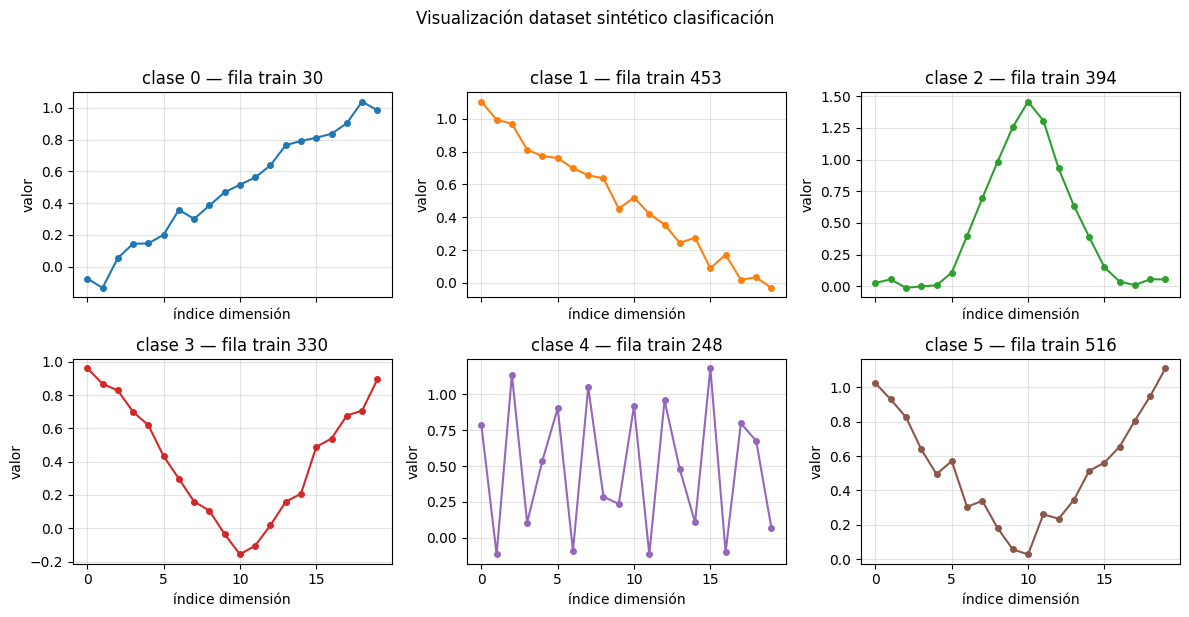

In [6]:
# Visualización de ejemplos sintéticos para comprobar la forma de cada clase.
t = np.arange(SEQ_LEN_SINT)
_rng_v = np.random.default_rng(RNG_SINT)

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
axes = axes.ravel()
for c in range(N_CLASSES_SINT):
    idx = np.where(y_sint_train_arr == c)[0]
    if len(idx) == 0:
        axes[c].set_visible(False)
        continue
    j = int(_rng_v.choice(idx))
    series = sint_x_train.iloc[j].values.astype(float)
    axes[c].plot(t, series, marker="o", markersize=4, color=plt.cm.tab10(c % 10))
    axes[c].set_title(f"clase {c} — fila train {j}")
    axes[c].set_xlabel("índice dimensión")
    axes[c].set_ylabel("valor")
    axes[c].grid(True, alpha=0.35)
plt.suptitle("Visualización dataset sintético clasificación", y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Entrenamiento repetido de GNN y RNN sobre el dataset sintético.
N_RUNS = 100
EPOCHS = 50
BATCH_SIZE = 32
LR= 1e-3

graphs_sint_train = []
graphs_sint_test = []

# Primero se crean los grafos de visibilidad que usará la GNN.
for i in range(len(sint_x_train)):
    input_seq = sint_x_train.iloc[i].values
    y_cls = int(y_sint_train_arr[i])
    g = create_visibility_graph(input_seq)
    g.y = torch.tensor([y_cls], dtype=torch.long)
    graphs_sint_train.append(g)

for i in range(len(sint_x_test)):
    input_seq = sint_x_test.iloc[i].values
    y_cls = int(y_sint_test_arr[i])
    g = create_visibility_graph(input_seq)
    g.y = torch.tensor([y_cls], dtype=torch.long)
    graphs_sint_test.append(g)

loader_train_sint = DataLoader(graphs_sint_train, batch_size=BATCH_SIZE, shuffle=True)
loader_test_sint = DataLoader(graphs_sint_test, batch_size=BATCH_SIZE, shuffle=False)

# Entrena la GNN y conserva el mejor estado según cross-entropy en test.
def train_sint_gnn():
    model = GCN_for_VG(
        in_features=1, hidden_dim=128, num_classes=N_CLASSES_SINT, dropout=0.25
    )
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loader_train = DataLoader(graphs_sint_train, batch_size=BATCH_SIZE, shuffle=True)
    loader_test = DataLoader(graphs_sint_test, batch_size=BATCH_SIZE, shuffle=False)

    best_test_ce = float("inf")
    best_state = None

    for epoch in range(EPOCHS):
        model.train()
        for batch in loader_train:
            optimizer.zero_grad()
            logits = model(batch.x, batch.edge_index, batch.batch, batch.ptr)
            loss = criterion(logits, batch.y.view(-1))
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            tl, yl = [], []
            for batch in loader_test:
                tl.append(model(batch.x, batch.edge_index, batch.batch, batch.ptr))
                yl.append(batch.y.view(-1))
            test_ce = criterion(torch.cat(tl, dim=0), torch.cat(yl, dim=0)).item()
            preds = torch.cat(tl, dim=0).argmax(dim=1).cpu().numpy()
            labels = torch.cat(yl, dim=0).cpu().numpy()

        if test_ce < best_test_ce:
            best_test_ce = test_ce
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    model.eval()
    final_preds, final_actuals = [], []
    with torch.no_grad():
        for batch in loader_test:
            logits = model(batch.x, batch.edge_index, batch.batch, batch.ptr)
            final_preds.extend(logits.argmax(dim=1).cpu().numpy())
            final_actuals.extend(batch.y.view(-1).cpu().numpy())

    acc = float(accuracy_score(final_actuals, final_preds))
    return acc, best_test_ce

# Entrena la RNN con las mismas particiones para poder comparar modelos.
def train_sint_rnn():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = RNNClassifier(
        input_size=1, hidden_size=64, num_layers=1, num_classes=N_CLASSES_SINT
    ).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    X_tr = X_sint_train_tensor.to(device)
    y_tr = sint_y_train_long.to(device)
    X_te = X_sint_test_tensor.to(device)
    y_te = sint_y_test_long.to(device)
    n = len(X_tr)

    best_test_ce = float("inf")
    best_state = None

    for epoch in range(EPOCHS):
        model.train()
        perm = torch.randperm(n, device=X_tr.device)
        for j in range(0, n, BATCH_SIZE):
            idx = perm[j : j + BATCH_SIZE]
            xb, yb = X_tr[idx], y_tr[idx]
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            logits_te = model(X_te)
            test_ce = criterion(logits_te, y_te).item()
            pred = logits_te.argmax(1).cpu().numpy()
            y_actual = y_te.cpu().numpy()

        if test_ce < best_test_ce:
            best_test_ce = test_ce
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        pred = model(X_te).argmax(1).cpu().numpy()
        y_actual = y_te.cpu().numpy()

    acc = float(accuracy_score(y_actual, pred))
    return acc, best_test_ce

sint_gnn_acc, sint_gnn_ce = [], []
sint_rnn_acc, sint_rnn_ce = [], []

np.random.seed(42)

# Se repite el entrenamiento para medir variabilidad entre ejecuciones.
for i in range(N_RUNS):
    acc_g, ce_g = train_sint_gnn()
    sint_gnn_acc.append(acc_g)
    sint_gnn_ce.append(ce_g)
    acc_r, ce_r = train_sint_rnn()
    sint_rnn_acc.append(acc_r)
    sint_rnn_ce.append(ce_r)
    if (i + 1) % 10 == 0 or i == 0:
        print(f"Run {i+1}/{N_RUNS}\n"
              f"  GNN - acc: {acc_g:.4f}, CE: {ce_g:.6f}\n"
              f"  RNN - acc: {acc_r:.4f}, CE: {ce_r:.6f}")

sint_gnn_acc = np.array(sint_gnn_acc)
sint_gnn_ce = np.array(sint_gnn_ce)
sint_rnn_acc = np.array(sint_rnn_acc)
sint_rnn_ce = np.array(sint_rnn_ce)

Run 1/100
  GNN - acc: 0.9550, CE: 0.137010
  RNN - acc: 0.9842, CE: 0.055774
Run 10/100
  GNN - acc: 0.9500, CE: 0.136838
  RNN - acc: 0.9917, CE: 0.044354
Run 20/100
  GNN - acc: 0.9525, CE: 0.136498
  RNN - acc: 0.9883, CE: 0.057731
Run 30/100
  GNN - acc: 0.9517, CE: 0.140620
  RNN - acc: 0.9867, CE: 0.042412
Run 40/100
  GNN - acc: 0.9475, CE: 0.137292
  RNN - acc: 0.9842, CE: 0.048382
Run 50/100
  GNN - acc: 0.9492, CE: 0.139663
  RNN - acc: 0.9858, CE: 0.052122
Run 60/100
  GNN - acc: 0.9508, CE: 0.144011
  RNN - acc: 0.9875, CE: 0.050387
Run 70/100
  GNN - acc: 0.9525, CE: 0.138274
  RNN - acc: 0.9908, CE: 0.061426
Run 80/100
  GNN - acc: 0.9508, CE: 0.142992
  RNN - acc: 0.9742, CE: 0.078158
Run 90/100
  GNN - acc: 0.9558, CE: 0.126269
  RNN - acc: 0.9850, CE: 0.049119
Run 100/100
  GNN - acc: 0.9575, CE: 0.135272
  RNN - acc: 0.9892, CE: 0.053711


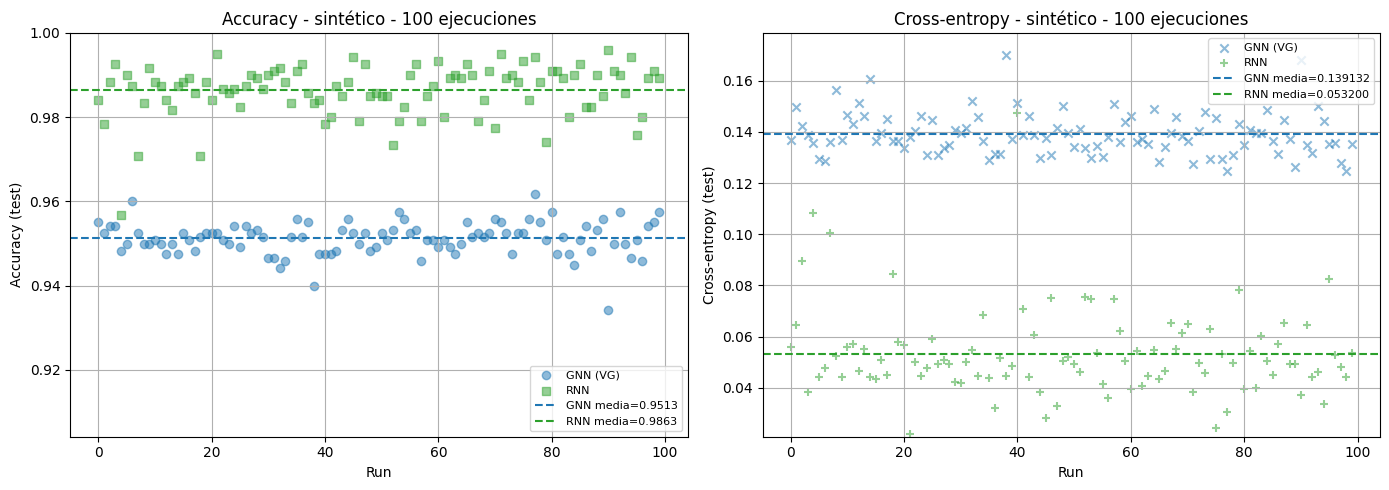


sintético — Modelo / Métrica                    Media       Varianza
GNN — Accuracy                                 0.9513     0.00001513
RNN — Accuracy                                 0.9863     0.00003696
GNN — Cross-entropy                          0.139132     0.00006962
RNN — Cross-entropy                          0.053200     0.00029810


In [ ]:
# Comparación gráfica y tabular de accuracy y cross-entropy en el dataset sintético.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

runs_sint = np.arange(N_RUNS)
axes[0].scatter(runs_sint, sint_gnn_acc, alpha=0.5, marker="o", color="tab:blue", label="GNN (VG)")
axes[0].scatter(runs_sint, sint_rnn_acc, alpha=0.5, marker="s", color="tab:green", label="RNN")
axes[0].axhline(
    sint_gnn_acc.mean(),
    color="tab:blue",
    linestyle="--",
    linewidth=1.5,
    label=f"GNN media={sint_gnn_acc.mean():.4f}",
)
axes[0].axhline(
    sint_rnn_acc.mean(),
    color="tab:green",
    linestyle="--",
    linewidth=1.5,
    label=f"RNN media={sint_rnn_acc.mean():.4f}",
)
axes[0].set_xlabel("Run")
axes[0].set_ylabel("Accuracy (test)")
axes[0].set_title(
    f"Accuracy - sintético - 100 ejecuciones"
)
axes[0].legend(loc="lower right", fontsize=8)
axes[0].grid(True)
lo = min(sint_gnn_acc.min(), sint_rnn_acc.min()) - 0.03
hi = max(sint_gnn_acc.max(), sint_rnn_acc.max()) + 0.03
axes[0].set_ylim(max(0.0, lo), min(1.0, hi))

axes[1].scatter(runs_sint, sint_gnn_ce, alpha=0.5, marker="x", color="tab:blue", label="GNN (VG)")
axes[1].scatter(runs_sint, sint_rnn_ce, alpha=0.5, marker="+", color="tab:green", label="RNN")
axes[1].axhline(
    sint_gnn_ce.mean(),
    color="tab:blue",
    linestyle="--",
    linewidth=1.5,
    label=f"GNN media={sint_gnn_ce.mean():.6f}",
)
axes[1].axhline(
    sint_rnn_ce.mean(),
    color="tab:green",
    linestyle="--",
    linewidth=1.5,
    label=f"RNN media={sint_rnn_ce.mean():.6f}",
)
axes[1].set_xlabel("Run")
axes[1].set_ylabel("Cross-entropy (test)")
axes[1].set_title(
    f"Cross-entropy - sintético - 100 ejecuciones"
)
axes[1].legend(loc="upper right", fontsize=8)
axes[1].grid(True)
lo_ce = min(sint_gnn_ce.min(), sint_rnn_ce.min()) * 0.95
hi_ce = max(sint_gnn_ce.max(), sint_rnn_ce.max()) * 1.05
axes[1].set_ylim(lo_ce, hi_ce)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"{'sintético — Modelo / Métrica':<40} {'Media':>12} {'Varianza':>14}")
print(f"{'='*60}")
print(f"{'GNN — Accuracy':<40} {sint_gnn_acc.mean():>12.4f} {sint_gnn_acc.var():>14.8f}")
print(f"{'RNN — Accuracy':<40} {sint_rnn_acc.mean():>12.4f} {sint_rnn_acc.var():>14.8f}")
print(f"{'GNN — Cross-entropy':<40} {sint_gnn_ce.mean():>12.6f} {sint_gnn_ce.var():>14.8f}")
print(f"{'RNN — Cross-entropy':<40} {sint_rnn_ce.mean():>12.6f} {sint_rnn_ce.var():>14.8f}")

# Melbourne Pedestrians

El dataset tiene 1194 casos train y 2439 casos test. Cada instancia tiene longitud 24 y mide la cantidad de viandantes en una zona de melbourne a cada hora del día. Hay 10 zonas, el objetivo es aprender a clasificarlas.

In [13]:
# Carga exploratoria del dataset Melbourne Pedestrian desde formato ARFF.
melbourne_data, melbourne_meta = arff.loadarff("C:/repositorios/MULCIA/TFM/MelbournePedestrian/MelbournePedestrian_TRAIN.arff")
melbourne_df = pd.DataFrame(melbourne_data)

for col in melbourne_df.columns:
    if melbourne_df[col].dtype == object:
        melbourne_df[col] = melbourne_df[col].apply(
            lambda x: x.decode("utf-8") if isinstance(x, bytes) else x
        )

In [14]:
# Carga de particiones train/test de Melbourne Pedestrian.
melbourne_train = path_arff_to_df("C:/repositorios/MULCIA/TFM/MelbournePedestrian/MelbournePedestrian_TRAIN.arff")
melbourne_test = path_arff_to_df("C:/repositorios/MULCIA/TFM/MelbournePedestrian/MelbournePedestrian_TEST.arff")

print(melbourne_train.shape, melbourne_test.shape)

(1194, 25) (2439, 25)


In [15]:
# Comprobación inicial de valores perdidos antes de preparar los datos.
print("Total de valores perdidos train:", melbourne_train.isnull().sum().sum())
print("Total de valores perdidos test:", melbourne_test.isnull().sum().sum())

Total de valores perdidos train: 82
Total de valores perdidos test: 171


In [16]:
# Limpieza de filas incompletas y separación de variables predictoras y clase.
melbourne_train = melbourne_train.dropna().reset_index(drop=True)
melbourne_test = melbourne_test.dropna().reset_index(drop=True)

print(melbourne_train.shape, melbourne_test.shape)

melb_x_train = melbourne_train.drop(columns=['target']).apply(pd.to_numeric, errors='coerce')
melb_y_train = melbourne_train['target']

melb_x_test = melbourne_test.drop(columns=['target']).apply(pd.to_numeric, errors='coerce')
melb_y_test = melbourne_test['target']

(1138, 25) (2319, 25)


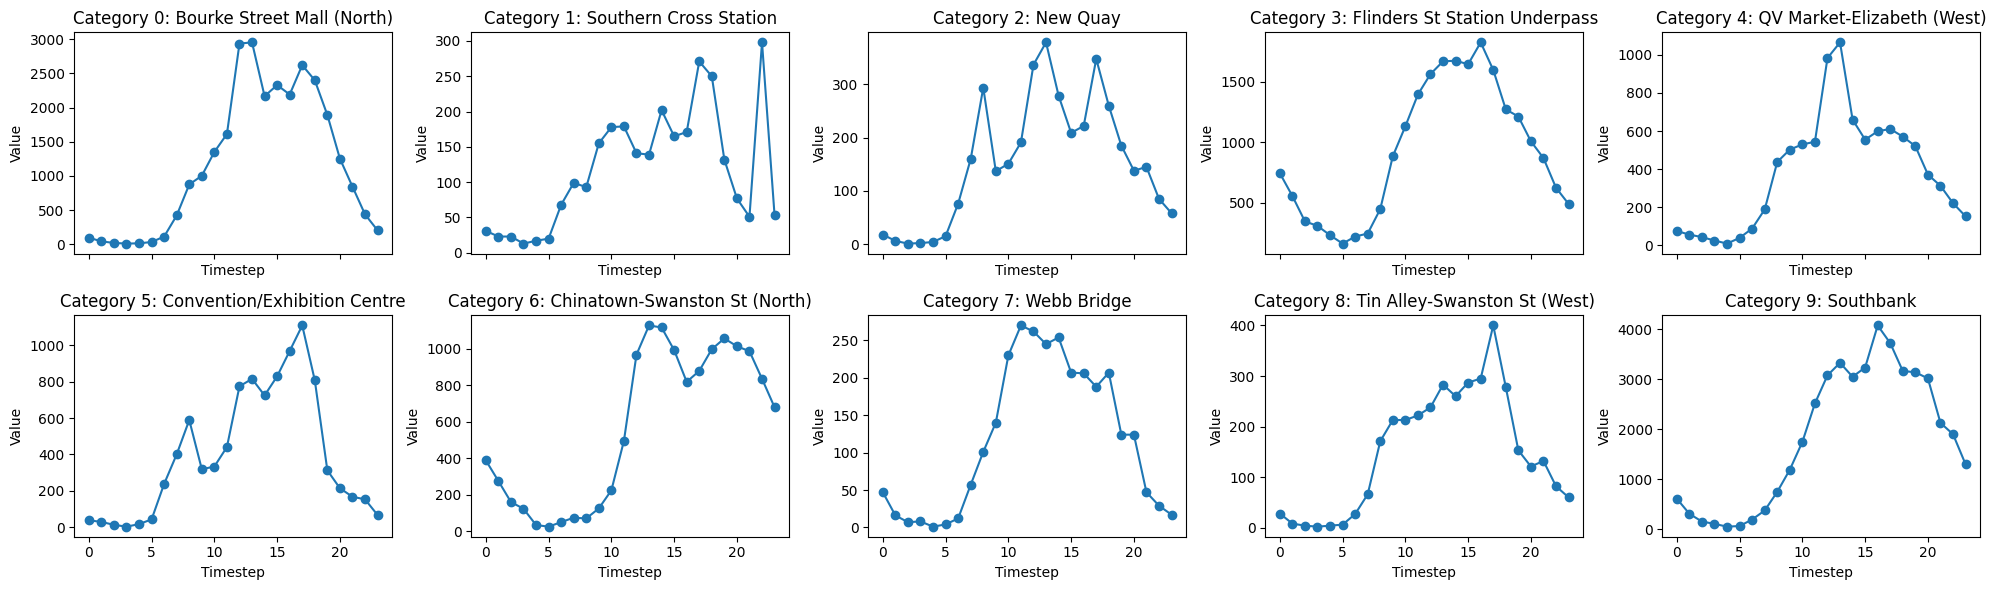

In [17]:
# Visualización de ejemplos para revisar la estructura de las series por clase.
import matplotlib.pyplot as plt

class_names = [
    "Bourke Street Mall (North)",
    "Southern Cross Station",
    "New Quay",
    "Flinders St Station Underpass",
    "QV Market-Elizabeth (West)",
    "Convention/Exhibition Centre",
    "Chinatown-Swanston St (North)",
    "Webb Bridge",
    "Tin Alley-Swanston St (West)",
    "Southbank"
]

ejemplos_idx = []
for clase in range(1, 11):
    idx = melb_y_train[melb_y_train == str(clase)].index[0]
    ejemplos_idx.append(idx)

fig, axes = plt.subplots(2, 5, figsize=(20, 6), sharex=True)
axes = axes.flatten()

for i, idx in enumerate(ejemplos_idx):
    timesteps = range(len(melb_x_train.loc[idx].values))
    valores = melb_x_train.loc[idx].values
    axes[i].plot(timesteps, valores, linestyle='-', marker='o')
    axes[i].set_title(f"Category {i}: {class_names[i]}")
    axes[i].set_xlabel("Timestep")
    axes[i].set_ylabel("Value")

plt.tight_layout()
plt.show()

## RNN

In [ ]:
# Transformación de Melbourne a tensores compatibles con la RNN.

X_train_tensor = torch.from_numpy(melb_x_train.to_numpy(dtype=np.float32)).unsqueeze(-1)
X_test_tensor = torch.from_numpy(melb_x_test.to_numpy(dtype=np.float32)).unsqueeze(-1)

y_train_tensor = torch.from_numpy(pd.to_numeric(melb_y_train, errors="coerce").astype(np.int64).values - 1).long()
y_test_tensor = torch.from_numpy(pd.to_numeric(melb_y_test, errors="coerce").astype(np.int64).values - 1).long()


# GNN

In [ ]:
# Construcción de grafos de visibilidad para cada serie de Melbourne.
graphs_mp_train = []
graphs_mp_test = []

for i in range(len(melb_x_train)):
    input_seq = melb_x_train.iloc[i].values if hasattr(melb_x_train, 'iloc') else melb_x_train[i]
    yi = melb_y_train.iloc[i] if hasattr(melb_y_train, 'iloc') else melb_y_train[i]
    y_cls = int(float(yi)) - 1

    graph_mp = create_visibility_graph(input_seq)
    graph_mp.y = torch.tensor([y_cls], dtype=torch.long)
    graphs_mp_train.append(graph_mp)

for i in range(len(melb_x_test)):
    input_seq = melb_x_test.iloc[i].values if hasattr(melb_x_test, 'iloc') else melb_x_test[i]
    yi = melb_y_test.iloc[i] if hasattr(melb_y_test, 'iloc') else melb_y_test[i]
    y_cls = int(float(yi)) - 1

    graph_mp = create_visibility_graph(input_seq)
    graph_mp.y = torch.tensor([y_cls], dtype=torch.long)
    graphs_mp_test.append(graph_mp)


## 100 Ejecuciones

In [ ]:
# Entrenamiento repetido de GNN y RNN sobre Melbourne Pedestrian.
NUM_CLASSES = 10

# Entrena la GNN y conserva el mejor estado según cross-entropy en test.
def train_melbourne_gnn():
    model = GCN_for_VG(
        in_features=1, hidden_dim=128, num_classes=NUM_CLASSES, dropout=0.25
    )
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loader_train = DataLoader(graphs_mp_train, batch_size=BATCH_SIZE, shuffle=True)
    loader_test = DataLoader(graphs_mp_test, batch_size=BATCH_SIZE, shuffle=False)

    best_test_ce = float("inf")
    best_state = None

    for epoch in range(EPOCHS):
        model.train()
        for batch in loader_train:
            optimizer.zero_grad()
            logits = model(batch.x, batch.edge_index, batch.batch, batch.ptr)
            loss = criterion(logits, batch.y.view(-1))
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            tl, yl = [], []
            for batch in loader_test:
                tl.append(model(batch.x, batch.edge_index, batch.batch, batch.ptr))
                yl.append(batch.y.view(-1))
            test_ce = criterion(torch.cat(tl, dim=0), torch.cat(yl, dim=0)).item()

        if test_ce < best_test_ce:
            best_test_ce = test_ce
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    model.eval()
    final_preds, final_actuals = [], []
    with torch.no_grad():
        for batch in loader_test:
            logits = model(batch.x, batch.edge_index, batch.batch, batch.ptr)
            final_preds.extend(logits.argmax(dim=1).cpu().numpy())
            final_actuals.extend(batch.y.view(-1).cpu().numpy())

    acc = float(accuracy_score(final_actuals, final_preds))
    return acc, best_test_ce


# Entrena la RNN con las mismas particiones para poder comparar modelos.
def train_melbourne_rnn():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = RNNClassifier(
        input_size=1, hidden_size=64, num_layers=1, num_classes=NUM_CLASSES
    ).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    X_tr = X_train_tensor.to(device)
    y_tr = y_train_tensor.to(device)
    X_te = X_test_tensor.to(device)
    y_te = y_test_tensor.to(device)
    n = len(X_tr)

    best_test_ce = float("inf")
    best_state = None

    for epoch in range(EPOCHS):
        model.train()
        perm = torch.randperm(n, device=X_tr.device)
        for j in range(0, n, BATCH_SIZE):
            idx = perm[j : j + BATCH_SIZE]
            xb, yb = X_tr[idx], y_tr[idx]
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            test_logits = model(X_te)
            test_ce = criterion(test_logits, y_te).item()

        if test_ce < best_test_ce:
            best_test_ce = test_ce
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        pred = model(X_te).argmax(1).cpu().numpy()
        y_actual = y_te.cpu().numpy()

    acc = float(accuracy_score(y_actual, pred))
    return acc, best_test_ce

melbourne_gnn_acc, melbourne_gnn_ce = [], []
melbourne_rnn_acc, melbourne_rnn_ce = [], []

np.random.seed(42)

# Se repite el entrenamiento para medir variabilidad entre ejecuciones.
for i in range(N_RUNS):
    acc_g, ce_g = train_melbourne_gnn()
    melbourne_gnn_acc.append(acc_g)
    melbourne_gnn_ce.append(ce_g)
    acc_r, ce_r = train_melbourne_rnn()
    melbourne_rnn_acc.append(acc_r)
    melbourne_rnn_ce.append(ce_r)
    if (i + 1) % 10 == 0 or i == 0:
        print(f"Run {i+1}/{N_RUNS} — GNN CE={ce_g:.4f}  RNN CE={ce_r:.4f}")

melbourne_gnn_acc = np.array(melbourne_gnn_acc)
melbourne_gnn_ce = np.array(melbourne_gnn_ce)
melbourne_rnn_acc = np.array(melbourne_rnn_acc)
melbourne_rnn_ce = np.array(melbourne_rnn_ce)


Run 1/100 — GNN CE=0.7771  RNN CE=0.7418
Run 10/100 — GNN CE=0.7453  RNN CE=0.8871
Run 20/100 — GNN CE=0.7543  RNN CE=1.0126
Run 30/100 — GNN CE=0.7791  RNN CE=0.7855
Run 40/100 — GNN CE=0.7401  RNN CE=0.7186
Run 50/100 — GNN CE=0.7783  RNN CE=0.7933
Run 60/100 — GNN CE=0.7567  RNN CE=0.8124
Run 70/100 — GNN CE=0.7605  RNN CE=0.8040
Run 80/100 — GNN CE=0.7613  RNN CE=0.8250
Run 90/100 — GNN CE=0.7493  RNN CE=0.7993
Run 100/100 — GNN CE=0.7685  RNN CE=0.6895


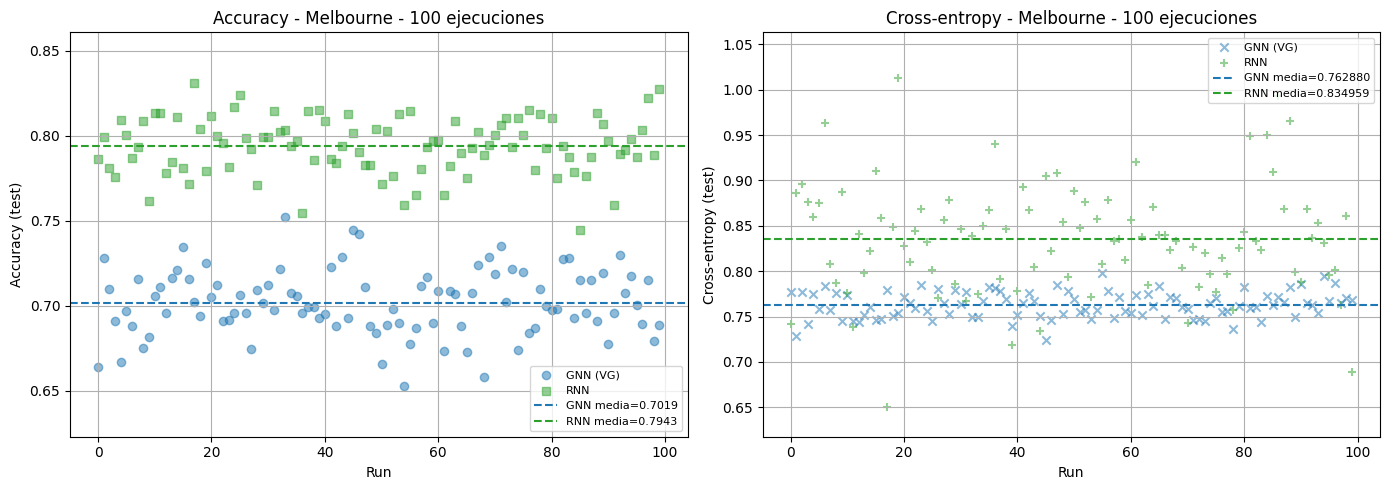


Modelo / Métrica                Media       Varianza
GNN — Accuracy                 0.7019     0.00036550
RNN — Accuracy                 0.7943     0.00027557
GNN — Cross-entropy          0.762880     0.00020938
RNN — Cross-entropy          0.834959     0.00365851


In [26]:
# Comparación gráfica y tabular de accuracy y cross-entropy en Melbourne.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

runs = np.arange(N_RUNS)
axes[0].scatter(runs, melbourne_gnn_acc, alpha=0.5, marker="o", color="tab:blue", label="GNN (VG)")
axes[0].scatter(runs, melbourne_rnn_acc, alpha=0.5, marker="s", color="tab:green", label="RNN")
axes[0].axhline(
    melbourne_gnn_acc.mean(),
    color="tab:blue",
    linestyle="--",
    linewidth=1.5,
    label=f"GNN media={melbourne_gnn_acc.mean():.4f}",
)
axes[0].axhline(
    melbourne_rnn_acc.mean(),
    color="tab:green",
    linestyle="--",
    linewidth=1.5,
    label=f"RNN media={melbourne_rnn_acc.mean():.4f}",
)
axes[0].set_xlabel("Run")
axes[0].set_ylabel("Accuracy (test)")
axes[0].set_title(f"Accuracy - Melbourne - 100 ejecuciones")
axes[0].legend(loc="lower right", fontsize=8)
axes[0].grid(True)
lo = min(melbourne_gnn_acc.min(), melbourne_rnn_acc.min()) - 0.03
hi = max(melbourne_gnn_acc.max(), melbourne_rnn_acc.max()) + 0.03
axes[0].set_ylim(max(0.0, lo), min(1.0, hi))

axes[1].scatter(runs, melbourne_gnn_ce, alpha=0.5, marker="x", color="tab:blue", label="GNN (VG)")
axes[1].scatter(runs, melbourne_rnn_ce, alpha=0.5, marker="+", color="tab:green", label="RNN")
axes[1].axhline(
    melbourne_gnn_ce.mean(),
    color="tab:blue",
    linestyle="--",
    linewidth=1.5,
    label=f"GNN media={melbourne_gnn_ce.mean():.6f}",
)
axes[1].axhline(
    melbourne_rnn_ce.mean(),
    color="tab:green",
    linestyle="--",
    linewidth=1.5,
    label=f"RNN media={melbourne_rnn_ce.mean():.6f}",
)
axes[1].set_xlabel("Run")
axes[1].set_ylabel("Cross-entropy (test)")
axes[1].set_title(f"Cross-entropy - Melbourne - 100 ejecuciones")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].grid(True)
lo_ce = min(melbourne_gnn_ce.min(), melbourne_rnn_ce.min()) * 0.95
hi_ce = max(melbourne_gnn_ce.max(), melbourne_rnn_ce.max()) * 1.05
axes[1].set_ylim(lo_ce, hi_ce)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"{'Modelo / Métrica':<24} {'Media':>12} {'Varianza':>14}")
print(f"{'='*60}")
print(f"{'GNN — Accuracy':<24} {melbourne_gnn_acc.mean():>12.4f} {melbourne_gnn_acc.var():>14.8f}")
print(f"{'RNN — Accuracy':<24} {melbourne_rnn_acc.mean():>12.4f} {melbourne_rnn_acc.var():>14.8f}")
print(f"{'GNN — Cross-entropy':<24} {melbourne_gnn_ce.mean():>12.6f} {melbourne_gnn_ce.var():>14.8f}")
print(f"{'RNN — Cross-entropy':<24} {melbourne_rnn_ce.mean():>12.6f} {melbourne_rnn_ce.var():>14.8f}")


# Smooth Subspace

El dataset tiene 150 casos train y 150 casos test. Los datos tienen longitud 15 y 3 posibles clases. Son sintéticos, para la clase 1 los cinco primeros datos son similares y los demás aleatorios; para la 2 ocurre igual con los datos 6 a 10 y con la 3 para los datos 11 a 15.

In [29]:
# Carga, limpieza y preparación del dataset SmoothSubspace.
smooth_train = path_arff_to_df("C:/repositorios/MULCIA/TFM/SmoothSubspace/SmoothSubspace_TRAIN.arff")
smooth_test = path_arff_to_df("C:/repositorios/MULCIA/TFM/SmoothSubspace/SmoothSubspace_TEST.arff")

print(smooth_train.shape, smooth_test.shape)
print("NaN train:", smooth_train.isnull().sum().sum(), "| NaN test:", smooth_test.isnull().sum().sum())

smooth_train = smooth_train.dropna().reset_index(drop=True)
smooth_test = smooth_test.dropna().reset_index(drop=True)

ss_x_train = smooth_train.drop(columns=["target"]).apply(pd.to_numeric, errors="coerce")
ss_y_train = smooth_train["target"]
ss_x_test = smooth_test.drop(columns=["target"]).apply(pd.to_numeric, errors="coerce")
ss_y_test = smooth_test["target"]

def preparar_tensors(datos_x, datos_y):
    y_arr = pd.to_numeric(datos_y, errors="coerce").astype(np.int64).values
    y_long = torch.from_numpy(y_arr - 1).long()
    x_np = datos_x.to_numpy(dtype=np.float32)
    x_tensor = torch.from_numpy(x_np).unsqueeze(-1)
    return x_tensor, y_long

X_ss_train_tensor, y_ss_train_tensor = preparar_tensors(ss_x_train, ss_y_train)
X_ss_test_tensor, y_ss_test_tensor = preparar_tensors(ss_x_test, ss_y_test)


(150, 16) (150, 16)
NaN train: 0 | NaN test: 0


In [ ]:
# Construcción de grafos de visibilidad para cada serie de SmoothSubspace.
graphs_ss_train = []
graphs_ss_test = []

for i in range(len(ss_x_train)):
    input_seq = ss_x_train.iloc[i].values if hasattr(ss_x_train, "iloc") else ss_x_train[i]
    yi = ss_y_train.iloc[i] if hasattr(ss_y_train, "iloc") else ss_y_train[i]
    y_cls = int(float(yi)) - 1
    g = create_visibility_graph(input_seq)
    g.y = torch.tensor([y_cls], dtype=torch.long)
    graphs_ss_train.append(g)

for i in range(len(ss_x_test)):
    input_seq = ss_x_test.iloc[i].values if hasattr(ss_x_test, "iloc") else ss_x_test[i]
    yi = ss_y_test.iloc[i] if hasattr(ss_y_test, "iloc") else ss_y_test[i]
    y_cls = int(float(yi)) - 1
    g = create_visibility_graph(input_seq)
    g.y = torch.tensor([y_cls], dtype=torch.long)
    graphs_ss_test.append(g)


# 100 ejecuciones

In [ ]:
# Entrenamiento repetido de GNN y RNN sobre SmoothSubspace.
NUM_CLASSES_SS = 3

# Entrena la GNN y conserva el mejor estado según cross-entropy en test.
def train_smooth_gnn():
    model = GCN_for_VG(
        in_features=1, hidden_dim=128, num_classes=NUM_CLASSES_SS, dropout=0.25
    )
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loader_train = DataLoader(graphs_ss_train, batch_size=BATCH_SIZE, shuffle=True)
    loader_test = DataLoader(graphs_ss_test, batch_size=BATCH_SIZE, shuffle=False)

    best_test_ce = float("inf")
    best_state = None

    for epoch in range(EPOCHS):
        model.train()
        for batch in loader_train:
            optimizer.zero_grad()
            logits = model(batch.x, batch.edge_index, batch.batch, batch.ptr)
            loss = criterion(logits, batch.y.view(-1))
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            tl, yl = [], []
            for batch in loader_test:
                tl.append(model(batch.x, batch.edge_index, batch.batch, batch.ptr))
                yl.append(batch.y.view(-1))
            test_ce = criterion(torch.cat(tl, dim=0), torch.cat(yl, dim=0)).item()

        if test_ce < best_test_ce:
            best_test_ce = test_ce
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    model.eval()
    final_preds, final_actuals = [], []
    with torch.no_grad():
        for batch in loader_test:
            logits = model(batch.x, batch.edge_index, batch.batch, batch.ptr)
            final_preds.extend(logits.argmax(dim=1).cpu().numpy())
            final_actuals.extend(batch.y.view(-1).cpu().numpy())

    acc = float(accuracy_score(final_actuals, final_preds))
    return acc, best_test_ce


# Entrena la RNN con las mismas particiones para poder comparar modelos.
def train_smooth_rnn():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = RNNClassifier(
        input_size=1, hidden_size=64, num_layers=1, num_classes=NUM_CLASSES_SS
    ).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    X_tr = X_ss_train_tensor.to(device)
    y_tr = y_ss_train_tensor.to(device)
    X_te = X_ss_test_tensor.to(device)
    y_te = y_ss_test_tensor.to(device)
    n = len(X_tr)

    best_test_ce = float("inf")
    best_state = None

    for epoch in range(EPOCHS):
        model.train()
        perm = torch.randperm(n, device=X_tr.device)
        for j in range(0, n, BATCH_SIZE):
            idx = perm[j : j + BATCH_SIZE]
            xb, yb = X_tr[idx], y_tr[idx]
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            test_ce = criterion(model(X_te), y_te).item()

        if test_ce < best_test_ce:
            best_test_ce = test_ce
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        pred = model(X_te).argmax(1).cpu().numpy()
        y_actual = y_te.cpu().numpy()

    acc = float(accuracy_score(y_actual, pred))
    return acc, best_test_ce

ss_gnn_acc, ss_gnn_ce = [], []
ss_rnn_acc, ss_rnn_ce = [], []

np.random.seed(42)

# Se repite el entrenamiento para medir variabilidad entre ejecuciones.
for i in range(N_RUNS):
    acc_g, ce_g = train_smooth_gnn()
    ss_gnn_acc.append(acc_g)
    ss_gnn_ce.append(ce_g)
    acc_r, ce_r = train_smooth_rnn()
    ss_rnn_acc.append(acc_r)
    ss_rnn_ce.append(ce_r)
    if (i + 1) % 10 == 0 or i == 0:
        print(f"Run {i+1}/{N_RUNS} — GNN ce={ce_g:.4f}  RNN ce={ce_r:.4f}")

ss_gnn_acc = np.array(ss_gnn_acc)
ss_gnn_ce = np.array(ss_gnn_ce)
ss_rnn_acc = np.array(ss_rnn_acc)
ss_rnn_ce = np.array(ss_rnn_ce)


Run 1/100 — GNN ce=0.7226  RNN ce=0.7176
Run 10/100 — GNN ce=0.7097  RNN ce=0.7265
Run 20/100 — GNN ce=0.6919  RNN ce=0.6520
Run 30/100 — GNN ce=0.6812  RNN ce=0.6513
Run 40/100 — GNN ce=0.6993  RNN ce=0.5851
Run 50/100 — GNN ce=0.6897  RNN ce=0.6003
Run 60/100 — GNN ce=0.6938  RNN ce=0.5931
Run 70/100 — GNN ce=0.6880  RNN ce=0.6625
Run 80/100 — GNN ce=0.6725  RNN ce=0.6869
Run 90/100 — GNN ce=0.7060  RNN ce=0.5906
Run 100/100 — GNN ce=0.6815  RNN ce=0.5946


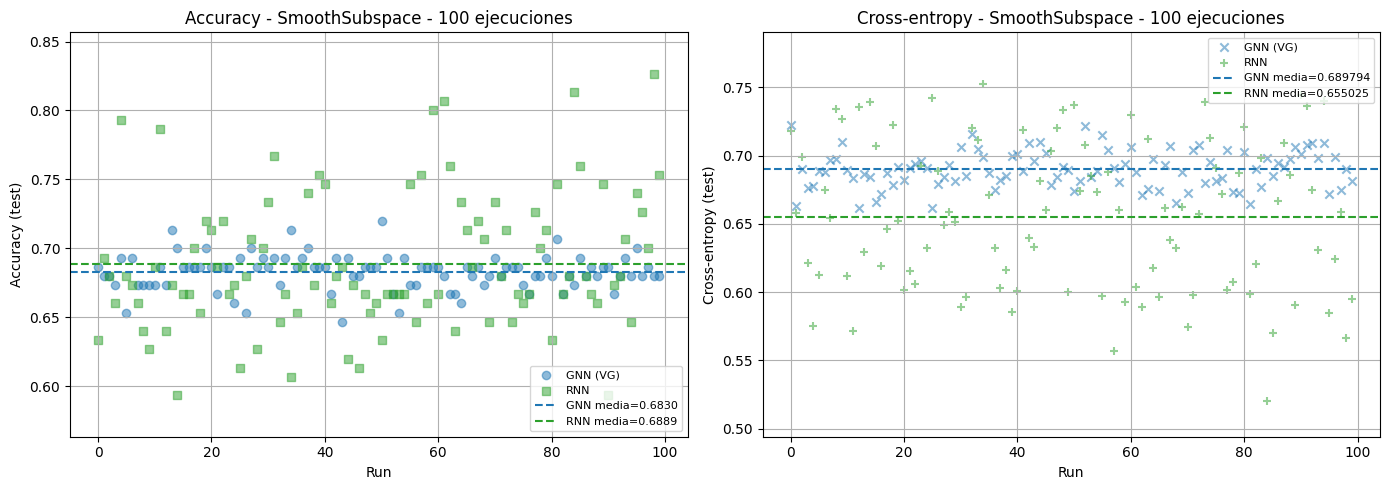


Modelo / Métrica                Media       Varianza
GNN — Accuracy                 0.6830     0.00015678
RNN — Accuracy                 0.6889     0.00236820
GNN — Cross-entropy          0.689794     0.00018197
RNN — Cross-entropy          0.655025     0.00297158


In [33]:
# Comparación gráfica y tabular de accuracy y cross-entropy en SmoothSubspace.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

runs_ss = np.arange(N_RUNS)
axes[0].scatter(runs_ss, ss_gnn_acc, alpha=0.5, marker="o", color="tab:blue", label="GNN (VG)")
axes[0].scatter(runs_ss, ss_rnn_acc, alpha=0.5, marker="s", color="tab:green", label="RNN")
axes[0].axhline(
    ss_gnn_acc.mean(),
    color="tab:blue",
    linestyle="--",
    linewidth=1.5,
    label=f"GNN media={ss_gnn_acc.mean():.4f}",
)
axes[0].axhline(
    ss_rnn_acc.mean(),
    color="tab:green",
    linestyle="--",
    linewidth=1.5,
    label=f"RNN media={ss_rnn_acc.mean():.4f}",
)
axes[0].set_xlabel("Run")
axes[0].set_ylabel("Accuracy (test)")
axes[0].set_title(f"Accuracy - SmoothSubspace - 100 ejecuciones")
axes[0].legend(loc="lower right", fontsize=8)
axes[0].grid(True)
lo = min(ss_gnn_acc.min(), ss_rnn_acc.min()) - 0.03
hi = max(ss_gnn_acc.max(), ss_rnn_acc.max()) + 0.03
axes[0].set_ylim(max(0.0, lo), min(1.0, hi))

axes[1].scatter(runs_ss, ss_gnn_ce, alpha=0.5, marker="x", color="tab:blue", label="GNN (VG)")
axes[1].scatter(runs_ss, ss_rnn_ce, alpha=0.5, marker="+", color="tab:green", label="RNN")
axes[1].axhline(
    ss_gnn_ce.mean(),
    color="tab:blue",
    linestyle="--",
    linewidth=1.5,
    label=f"GNN media={ss_gnn_ce.mean():.6f}",
)
axes[1].axhline(
    ss_rnn_ce.mean(),
    color="tab:green",
    linestyle="--",
    linewidth=1.5,
    label=f"RNN media={ss_rnn_ce.mean():.6f}",
)
axes[1].set_xlabel("Run")
axes[1].set_ylabel("Cross-entropy (test)")
axes[1].set_title(f"Cross-entropy - SmoothSubspace - 100 ejecuciones")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].grid(True)
lo_ce = min(ss_gnn_ce.min(), ss_rnn_ce.min()) * 0.95
hi_ce = max(ss_gnn_ce.max(), ss_rnn_ce.max()) * 1.05
axes[1].set_ylim(lo_ce, hi_ce)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"{'Modelo / Métrica':<24} {'Media':>12} {'Varianza':>14}")
print(f"{'='*60}")
print(f"{'GNN — Accuracy':<24} {ss_gnn_acc.mean():>12.4f} {ss_gnn_acc.var():>14.8f}")
print(f"{'RNN — Accuracy':<24} {ss_rnn_acc.mean():>12.4f} {ss_rnn_acc.var():>14.8f}")
print(f"{'GNN — Cross-entropy':<24} {ss_gnn_ce.mean():>12.6f} {ss_gnn_ce.var():>14.8f}")
print(f"{'RNN — Cross-entropy':<24} {ss_rnn_ce.mean():>12.6f} {ss_rnn_ce.var():>14.8f}")